In [93]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict
import numpy as np

import matplotlib.pyplot as plt

import yaml
from pathlib import Path

from thesis_project.datasets import SpeechCommandsGoogle
from thesis_project.utils.paths import get_data_dir

from thesis_project.models.architectures.keyword_spotting import KeyWordSpottingModel, KeyWordSpottingConfig, SpectrogramConfig, BackboneConfig, NoiseConfig

In [94]:
SKIP_TRAINING = True

In [95]:

# --- Load YAML file ---
config_path = Path("/Users/christoffer/Documents/Thesis/thesis_project/src/thesis_project/models/architectures/keyword_spotting/keyword_spotting_config.yaml")
with open(config_path, "r") as f:
    raw_cfg = yaml.safe_load(f)

# --- Parse and validate with Pydantic ---
cfg = KeyWordSpottingConfig(
    spectrogram=SpectrogramConfig(**raw_cfg["spectrogram"]),
    backbone=BackboneConfig(**raw_cfg["backbone"]),
    noise=NoiseConfig(**raw_cfg["noise"]),
    num_classes=raw_cfg.get("num_classes", 35),
)
model = KeyWordSpottingModel(cfg)
data_dir = get_data_dir()
train_set = SpeechCommandsGoogle(root=str(data_dir), subset="training", download=True, **cfg.noise.model_dump())
val_set = SpeechCommandsGoogle(root=str(data_dir), subset="validation", download=True, **cfg.noise.model_dump())

In [96]:
# Training configuration
batch_size = 32
num_epochs = 10
learning_rate = 0.001

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Create data loaders (no num_workers for MPS compatibility)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

# Move model to device
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


Using MPS


In [97]:
if not SKIP_TRAINING:
    # Training loop
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for waveforms, labels, _ in train_pbar:  # Dataset returns (waveform, label, metadata)
            waveforms, labels = waveforms.to(device), labels.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            logits = model(waveforms)
            loss = criterion(logits, labels)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            # Statistics
            train_loss += loss.item() * waveforms.size(0)
            _, predicted = torch.max(logits, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            # Update progress bar
            train_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * train_correct / train_total:.2f}%'
            })
        
        train_loss = train_loss / len(train_set)
        train_acc = 100 * train_correct / train_total
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
            for waveforms, labels, _ in val_pbar:  # Dataset returns (waveform, label, metadata)
                waveforms, labels = waveforms.to(device), labels.to(device)
                
                # Forward pass
                logits = model(waveforms)
                loss = criterion(logits, labels)
                
                # Statistics
                val_loss += loss.item() * waveforms.size(0)
                _, predicted = torch.max(logits, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
                # Update progress bar
                val_pbar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{100 * val_correct / val_total:.2f}%'
                })
        
        val_loss = val_loss / len(val_set)
        val_acc = 100 * val_correct / val_total
        
        # Print epoch summary
        print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        print("-" * 60)

    print("Training completed!")
    # save the model
    torch.save(model.state_dict(), "keyword_spotting_model.pth")

In [98]:
# load the model
model.load_state_dict(torch.load("keyword_spotting_model.pth"))

<All keys matched successfully>

In [99]:
def validate_model_per_noise(model, val_loader, criterion, device, noise_params=None,verbose=True):
    """
    Validate the model and report both overall accuracy and accuracy per noise_param value.
    Assumes each batch includes metadata["noise_param"] for every sample.
    """
    if noise_params is None:
        noise_params = cfg.noise.noise_params
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # Track stats per noise level
    noise_stats = {np: {"correct": 0, "total": 0, "loss": 0.0} for np in noise_params} if noise_params else {}

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc="Validation")
        for waveforms, labels, meta_data in val_pbar:
            waveforms, labels = waveforms.to(device), labels.to(device)
            
            logits = model(waveforms)
            loss = criterion(logits, labels)

            # Predictions
            _, predicted = torch.max(logits, 1)
            correct = (predicted == labels).sum().item()

            # Update overall stats
            batch_size = labels.size(0)
            val_total += batch_size
            val_correct += correct
            val_loss += loss.item() * batch_size

            # Update per-noise stats
            noise_params_batch = meta_data["noise_param"] if isinstance(meta_data, dict) else [m["noise_param"] for m in meta_data]
            for i, noise_param in enumerate(noise_params_batch):
                noise_stats[float(noise_param)]["total"] += 1
                noise_stats[float(noise_param)]["correct"] += int(predicted[i] == labels[i])
                noise_stats[float(noise_param)]["loss"] += loss.item()

            # Progress bar
            val_pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{100 * val_correct / val_total:.2f}%"
            })

    # Compute averages
    val_loss /= val_total
    val_acc = 100 * val_correct / val_total

    # Compute per-noise accuracy/loss
    per_noise = {
        np: {
            "acc": 100 * v["correct"] / v["total"] if v["total"] > 0 else 0.0,
            "loss": v["loss"] / v["total"] if v["total"] > 0 else 0.0,
        }
        for np, v in sorted(noise_stats.items())
    }
    if verbose:
        # Print or return as you prefer
        print("\n=== Accuracy per noise_param ===")
        for np, v in per_noise.items():
            print(f"  noise={np:>6}: acc={v['acc']:.2f}%  loss={v['loss']:.4f}")

    return val_loss, val_acc, per_noise

In [100]:
val_loss, val_acc, per_noise = validate_model_per_noise(model, val_loader, criterion, device)
print(f"Final Validation Loss: {val_loss:.4f}, Final Validation Acc: {val_acc:.2f}%")

Validation: 100%|██████████| 312/312 [00:10<00:00, 29.25it/s, loss=1.0685, acc=54.00%]


=== Accuracy per noise_param ===
  noise=   0.0: acc=71.49%  loss=1.6248
  noise=  0.05: acc=68.76%  loss=1.6200
  noise=   0.1: acc=57.23%  loss=1.6194
  noise=  0.15: acc=50.00%  loss=1.6168
  noise=   0.2: acc=40.96%  loss=1.6155
  noise=  0.25: acc=35.07%  loss=1.6205
Final Validation Loss: 1.6195, Final Validation Acc: 54.00%


In [101]:
def evaluate_rank_sweep(
    model,
    compressible_layers,
    validate_fn,
    val_loader,
    criterion,
    device,
    max_rank,
    step=4,
    compress_frontend=False,
    verbose=True,
):
    """
    Sweep across target ranks for CPC_Conv1d layers and record validation accuracy.

    Args:
        model (nn.Module): Your model containing CPC_Conv1d layers.
        compressible_layers (list[tuple[str, nn.Module]]): (name, layer) pairs of CPC_Conv1d layers.
        validate_fn (callable): Validation function (model, val_loader, criterion, device) -> (val_loss, val_acc)
        val_loader (DataLoader): Validation dataloader.
        criterion (nn.Module): Loss function.
        device (torch.device): Torch device.
        max_rank (int): Maximum rank (usually = in_channels = out_channels).
        step (int, optional): Step size for the rank sweep. Default = 4.
        compress_frontend (bool, optional): If False, skip compressing the "frontend" layer.
        verbose (bool, optional): Print progress messages.

    Returns:
        list[tuple[int, float]]: List of (target_rank, val_acc) results.
    """
    val_acc_results = []

    for target_rank in range(step, max_rank + 1, step):
        # --- Activate low-rank ---
        for name, layer in compressible_layers:
            if (not compress_frontend) and (name == "frontend"):
                continue
            layer.activate_low_rank(rank=target_rank)

        # --- Validate ---
        val_loss, val_acc, per_noise = validate_fn(model, val_loader, criterion, device, verbose=False)
        val_acc_results.append((target_rank, per_noise))

        if verbose:
            print(f"[Rank {target_rank:>3}] Val Acc: {val_acc:.3f}")

    return val_acc_results


In [102]:
def plot_rank_vs_accuracy_by_noise(
    results,                 # list of (rank: int, per_noise: dict[noise_param -> {'acc': float, 'loss': float}])
    title=None,
    save_path=None,
    metric="acc",            # "acc" or "loss"
    show_flops=True,         # keep the secondary y-axis like before
):
    """
    Plot {metric} vs. rank with one curve per noise_param.

    Example input:
    results = [
        (4, {0.0:{'acc':14.76,'loss':4.07}, 0.05:{'acc':21.62,'loss':4.06}}),
        (8, {0.0:{'acc':20.65,'loss':4.06}, 0.05:{'acc':34.11,'loss':4.05}})
    ]
    """

    # --- collect and sort ranks ---
    ranks = sorted(int(r) for r, _ in results)
    rank_to_dict = {int(r): d for r, d in results}

    # --- gather all noise params across ranks ---
    all_noise = set()
    for d in rank_to_dict.values():
        for k in d.keys():
            try:
                all_noise.add(float(k))
            except Exception:
                # ignore non-numeric noise keys
                pass
    noise_params = sorted(all_noise)  # numeric sort

    # --- build series per noise param aligned to 'ranks' order ---
    series = {}  # noise_param -> list of metric values aligned with ranks
    for np_val in noise_params:
        vals = []
        for r in ranks:
            entry = rank_to_dict[r].get(np_val, None)
            if entry is None or metric not in entry:
                vals.append(np.nan)  # missing value creates a gap in the curve
            else:
                vals.append(entry[metric])
        series[np_val] = vals

    # --- relative FLOPs for PW conv (same as your original logic) ---
    C = max(ranks) if ranks else 1
    flops_rel = [2 * r / C for r in ranks]  # =1 when r=C/2

    # --- plot ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # left axis: metric per noise
    for np_val, vals in series.items():
        ax1.plot(ranks, vals, marker='o', label=f"noise std={np_val:g}")

    ax1.set_xlabel("Target Rank")
    ylab = "Validation Accuracy (%)" if metric == "acc" else "Validation Loss"
    ax1.set_ylabel(ylab)
    ax1.grid(True, alpha=0.4)

    # helpful vertical reference at C//2
    ax1.axvline(x=C // 2, color='r', linestyle='--', linewidth=1, label='Max Rank // 2')

    # right axis: relative FLOPs (optional)
    if show_flops:
        ax2 = ax1.twinx()
        ax2.plot(ranks, flops_rel, linestyle='-', alpha=0.6, label="Relative PW FLOPs")
        ax2.set_ylabel("Relative PW FLOPs (vs full conv)")
        # Handle legends from both axes
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    else:
        ax1.legend(loc="best")

    # title
    if title is None:
        base = "Validation Accuracy vs. Target Rank" if metric == "acc" \
               else "Validation Loss vs. Target Rank"
        if show_flops:
            base += " (with Relative PW FLOPs)"
        title = base
    plt.title(title)

    # save or show
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Plot saved to {save_path}")
        plt.close(fig)
    else:
        plt.tight_layout()
        plt.show()


In [103]:
from thesis_project.models.blocks import CPC_Conv1d
compressible_layers = []
for name, layer in model.named_modules():
    if isinstance(layer, CPC_Conv1d):
        W = layer.weight_full.squeeze(-1)
        max_rank = min(W.shape)
        print(f"{name}: max_rank = {max_rank}")
        compressible_layers.append((name, layer))

backbone.0.0.cpw_conv1: max_rank = 128
backbone.0.0.cpw_conv2: max_rank = 128
backbone.0.1.cpw_conv1: max_rank = 128
backbone.0.1.cpw_conv2: max_rank = 128
backbone.0.2.cpw_conv1: max_rank = 128
backbone.0.2.cpw_conv2: max_rank = 128
frontend: max_rank = 128


In [104]:
results = {}

results["val_acc_results"] = evaluate_rank_sweep(
    model=model,
    compressible_layers=compressible_layers,
    validate_fn=validate_model_per_noise,
    val_loader=val_loader,
    criterion=criterion,    
    device=device,
    max_rank=128, #128
    step=4,
    compress_frontend=False,
    verbose=True
)

Validation: 100%|██████████| 312/312 [00:10<00:00, 29.19it/s, loss=6.3966, acc=12.69%]


[Rank   4] Val Acc: 12.694


Validation: 100%|██████████| 312/312 [00:10<00:00, 29.57it/s, loss=5.2679, acc=23.46%]


[Rank   8] Val Acc: 23.465


Validation: 100%|██████████| 312/312 [00:10<00:00, 29.47it/s, loss=1.6834, acc=37.09%]


...

[Rank 120] Val Acc: 53.792


Validation: 100%|██████████| 312/312 [00:11<00:00, 26.87it/s, loss=1.0293, acc=54.06%]


[Rank 124] Val Acc: 54.063


Validation: 100%|██████████| 312/312 [00:11<00:00, 27.48it/s, loss=1.0049, acc=54.17%]

[Rank 128] Val Acc: 54.173


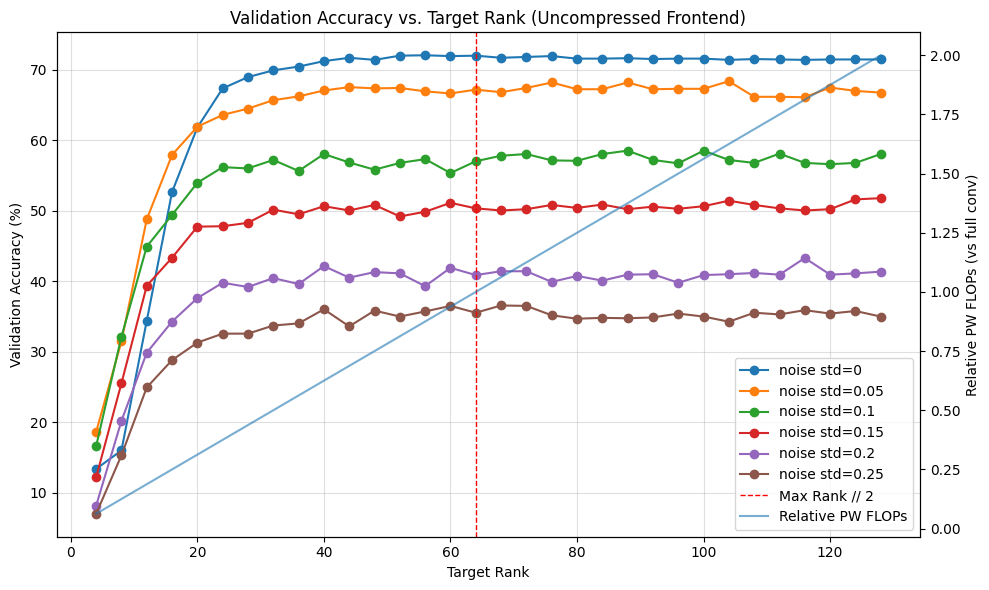

In [105]:
plot_rank_vs_accuracy_by_noise(
    results=results["val_acc_results"],
    title="Validation Accuracy vs. Target Rank (Uncompressed Frontend)",
    metric="acc",
    show_flops=True
)

### COMPRESSED FRONTEND RESULTS

In [106]:
results["val_acc_results_compressed_frontend"] = evaluate_rank_sweep(
    model=model,
    compressible_layers=compressible_layers,
    validate_fn=validate_model_per_noise,
    val_loader=val_loader,
    criterion=criterion,    
    device=device,
    max_rank=128, #128
    step=4,
    compress_frontend=True,
    verbose=True
)

Validation: 100%|██████████| 312/312 [00:10<00:00, 28.75it/s, loss=5.5129, acc=6.57%] 


[Rank   4] Val Acc: 6.572


Validation: 100%|██████████| 312/312 [00:11<00:00, 28.24it/s, loss=3.8002, acc=17.59%]


[Rank   8] Val Acc: 17.593


Validation: 100%|██████████| 312/312 [00:10<00:00, 29.36it/s, loss=2.2034, acc=30.81%]


...

[Rank 120] Val Acc: 54.413


Validation: 100%|██████████| 312/312 [00:10<00:00, 29.83it/s, loss=0.9266, acc=53.88%]


[Rank 124] Val Acc: 53.882


Validation: 100%|██████████| 312/312 [00:10<00:00, 29.59it/s, loss=1.0205, acc=53.81%]

[Rank 128] Val Acc: 53.812


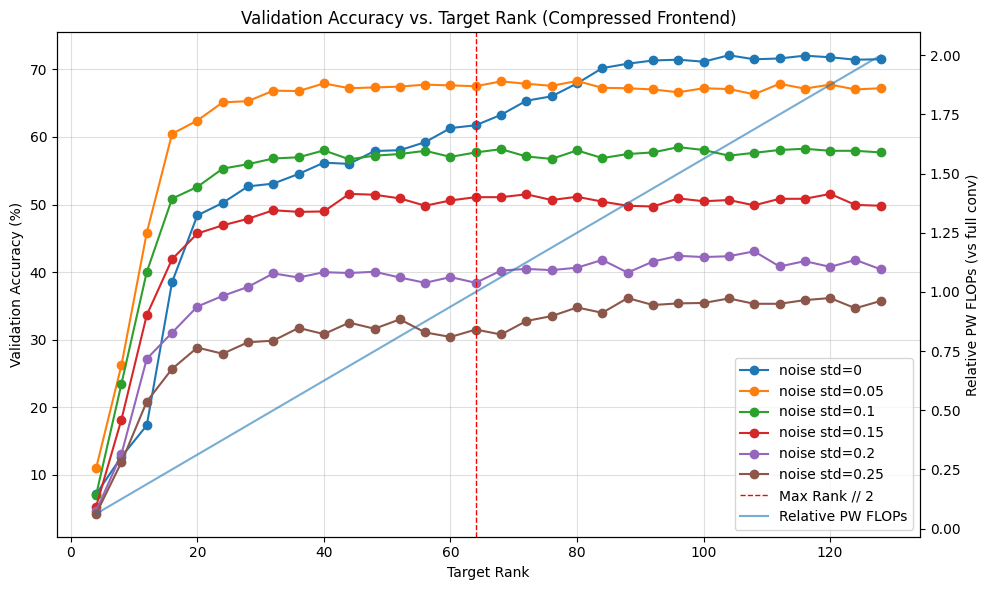

In [107]:
plot_rank_vs_accuracy_by_noise(
    results=results["val_acc_results_compressed_frontend"],
    title="Validation Accuracy vs. Target Rank (Compressed Frontend)",
    metric="acc",
    show_flops=True
)